In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import importlib
import benchmarks
import itertools
import h5py
import glob
import os
import sys
from scipy.spatial.transform import Rotation as R
from scipy.interpolate import interp1d
importlib.reload(benchmarks)

import matplotlib.pylab as pylab
params = {'figure.titlesize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large'}

pylab.rcParams.update(params)

def get_formatter():
    formatter = mticker.ScalarFormatter(useMathText=True)  # Ensures 'e' notation instead of '10^x'
    formatter.set_scientific(True)  # Keep scientific notation
    formatter.set_powerlimits((-1, 1))  # Defines when scientific notation should be used
    return formatter

In [2]:
physics = {'B0' : '5e-6, 0, 0',
           'L' : '1.0, 1.0, 1.0',
           'yi' : '0.0, 1.0, 0.0',
           'm' : '1.20239e-26',
           't0' : '0.0',
           'tf' : '1.0',
           'gamma' : '-2.038e8',
           'a' : '0.0',
           'w' : '6.28318530718e3',
           'diffuse' : '0.0',
           'gas_coll' : 'true',
           'gravity' : 'false',
           'dist' : 'M'}

integration = {'numParticles' : '8192',
               'numPerGPUBlock' : '256',
               'integratorType' : '6',
               'seed' : 'rand',
               'h': '1e-4'}
               #'stopTimes': '0.980:0.001:0.999'}

scratch_dir = '/storage/home/hcodaman1/rtat3/scratch'

In [3]:
if os.path.isdir('/usr/local/pace-apps/lmod/lmod/init/'):
    # Specifically for the PACE cluster
    sys.path.append('/usr/local/pace-apps/lmod/lmod/init/')
    from env_modules_python import module
    module('load', 'nvhpc', 'gcc', 'openmpi', 'cuda', 'hdf5')


Lmod is automatically replacing "nvhpc-nvc/24.5" with "gcc/12.3.0".




In [4]:
def compute_rotation(x0, y0, xf, yf):
    V0 = np.hstack((x0, y0, np.cross(x0.T, y0.T).T))
    Vf = np.hstack((xf, yf, np.cross(xf.T, yf.T).T))
    return Vf @ np.linalg.inv(V0)

def grab_vector(compiled_data, t, iType, E):
    mask = (compiled_data['tf'] == t) & (compiled_data['iType'] == iType) & (compiled_data['E'] == E)
    sel = compiled_data[mask]
    return np.mean(np.vstack((sel['sx'], sel['sy'], sel['sz'])), axis=1, keepdims=True)

def rotation_from_data(compiled_data, iType, E=1e7):
    ts = np.unique(compiled_data['tf'])
    idt = 4
    x0 = grab_vector(compiled_data, ts[-1-idt], iType, E)
    y0 = grab_vector(compiled_data, ts[-1-idt*2], iType, E)
    xf = grab_vector(compiled_data, ts[-1], iType, E)
    yf = x0
    return compute_rotation(x0, y0, xf, yf)

def smooth_theory(x, y, kind='quadratic', num=50):
    fit_func = interp1d(pred_x, pred_y, kind=kind)
    xres = np.linspace(min(x), max(x), num=num)
    return xres, fit_func(xres)

In [5]:
dressing_B2_windowing_folder = 'dressing_B2_windowing_test'

In [19]:
Gzz_range = np.linspace(0, 3e-9, num=5)
E_range = np.linspace(0, 1e7, num=5)

T_range = [0.25]
a_range = [3e-5]
parameter_tuples = [('0', '1.0')] + [x for x in itertools.product(('6', '7'), ('0.01', '0.1', '1.0'))]
for _ in range(4):
    for (iType, ioutInt) in parameter_tuples:
        integration['integratorType'] = iType
        integration['ioutInt'] = ioutInt
        pb = benchmarks.DressingBenchmark(physics=physics, integration=integration,
                                            Gzz_range = Gzz_range,
                                            T_range = T_range,
                                            a_range = a_range,
                                            executable='../build/cuda/main', scratch_dir=os.path.join(scratch_dir, dressing_B2_windowing_folder))
        pb.run()

Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 14
iter 1, duration 1, 5911
{0.140134, -0.221564, 0.965024}
6277
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 14
iter 1, duration 1, 5924
{0.140134, -0.221565, 0.965024}
6193
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 13
iter 1, duration 1, 5868
{0.140131, -0.221569, 0.965024}
6136
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 13
iter 1, duration 1, 5920
{0.140127, -0.221575, 0.965023}
6180
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 5988
{0.140135, -0.221583, 0.96502}
6262
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
it

iter 58, duration 0.58, 22
iter 59, duration 0.59, 22
iter 60, duration 0.6, 22
iter 61, duration 0.61, 24
iter 62, duration 0.62, 23
iter 63, duration 0.63, 22
iter 64, duration 0.64, 22
iter 65, duration 0.65, 23
iter 66, duration 0.66, 22
iter 67, duration 0.67, 23
iter 68, duration 0.68, 22
iter 69, duration 0.69, 22
iter 70, duration 0.7, 22
iter 71, duration 0.71, 23
iter 72, duration 0.72, 22
iter 73, duration 0.73, 22
iter 74, duration 0.74, 23
iter 75, duration 0.75, 23
iter 76, duration 0.76, 22
iter 77, duration 0.77, 22
iter 78, duration 0.78, 23
iter 79, duration 0.79, 23
iter 80, duration 0.8, 23
iter 81, duration 0.81, 24
iter 82, duration 0.82, 23
iter 83, duration 0.83, 22
iter 84, duration 0.84, 23
iter 85, duration 0.85, 22
iter 86, duration 0.86, 22
iter 87, duration 0.87, 22
iter 88, duration 0.88, 22
iter 89, duration 0.89, 22
iter 90, duration 0.9, 23
iter 91, duration 0.91, 22
iter 92, duration 0.92, 23
iter 93, duration 0.93, 24
iter 94, duration 0.94, 23
iter 

iter 0, duration 0, 6
iter 1, duration 0.1, 277
iter 2, duration 0.2, 271
iter 3, duration 0.3, 272
iter 4, duration 0.4, 274
iter 5, duration 0.5, 270
iter 6, duration 0.6, 270
iter 7, duration 0.7, 277
iter 8, duration 0.8, 270
iter 9, duration 0.9, 280
iter 10, duration 1, 275
{0.140133, -0.221575, 0.965021}
3004
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 0.1, 276
iter 2, duration 0.2, 275
iter 3, duration 0.3, 275
iter 4, duration 0.4, 270
iter 5, duration 0.5, 277
iter 6, duration 0.6, 268
iter 7, duration 0.7, 281
iter 8, duration 0.8, 268
iter 9, duration 0.9, 269
iter 10, duration 1, 268
{0.140133, -0.221583, 0.965019}
2996
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2453
{0.140134, -0.221564, 0.965024}
2716
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive ad

iter 39, duration 0.39, 1
iter 40, duration 0.4, 1
iter 41, duration 0.41, 1
iter 42, duration 0.42, 1
iter 43, duration 0.43, 1
iter 44, duration 0.44, 1
iter 45, duration 0.45, 1
iter 46, duration 0.46, 1
iter 47, duration 0.47, 1
iter 48, duration 0.48, 1
iter 49, duration 0.49, 1
iter 50, duration 0.5, 1
iter 51, duration 0.51, 1
iter 52, duration 0.52, 1
iter 53, duration 0.53, 1
iter 54, duration 0.54, 1
iter 55, duration 0.55, 1
iter 56, duration 0.56, 1
iter 57, duration 0.57, 1
iter 58, duration 0.58, 1
iter 59, duration 0.59, 1
iter 60, duration 0.6, 1
iter 61, duration 0.61, 1
iter 62, duration 0.62, 1
iter 63, duration 0.63, 1
iter 64, duration 0.64, 1
iter 65, duration 0.65, 1
iter 66, duration 0.66, 1
iter 67, duration 0.67, 1
iter 68, duration 0.68, 1
iter 69, duration 0.69, 1
iter 70, duration 0.7, 1
iter 71, duration 0.71, 1
iter 72, duration 0.72, 1
iter 73, duration 0.73, 1
iter 74, duration 0.74, 1
iter 75, duration 0.75, 1
iter 76, duration 0.76, 1
iter 77, duratio

iter 8, duration 0.8, 15
iter 9, duration 0.9, 15
iter 10, duration 1, 15
{0.140134, -0.22157, 0.965023}
614
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 25
iter 1, duration 0.1, 16
iter 2, duration 0.2, 15
iter 3, duration 0.3, 16
iter 4, duration 0.4, 15
iter 5, duration 0.5, 16
iter 6, duration 0.6, 16
iter 7, duration 0.7, 15
iter 8, duration 0.8, 15
iter 9, duration 0.9, 15
iter 10, duration 1, 16
{0.140133, -0.221578, 0.965021}
603
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 25
iter 1, duration 0.1, 15
iter 2, duration 0.2, 15
iter 3, duration 0.3, 15
iter 4, duration 0.4, 15
iter 5, duration 0.5, 15
iter 6, duration 0.6, 15
iter 7, duration 0.7, 15
iter 8, duration 0.8, 15
iter 9, duration 0.9, 15
iter 10, duration 1, 15
{0.140133, -0.221589, 0.965018}
615
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusi

...

iter 4, duration 0.04, 1
iter 5, duration 0.05, 1
iter 6, duration 0.06, 1
iter 7, duration 0.07, 1
iter 8, duration 0.08, 1
iter 9, duration 0.09, 1
iter 10, duration 0.1, 1
iter 11, duration 0.11, 1
iter 12, duration 0.12, 1
iter 13, duration 0.13, 1
iter 14, duration 0.14, 1
iter 15, duration 0.15, 1
iter 16, duration 0.16, 1
iter 17, duration 0.17, 1
iter 18, duration 0.18, 1
iter 19, duration 0.19, 1
iter 20, duration 0.2, 1
iter 21, duration 0.21, 1
iter 22, duration 0.22, 1
iter 23, duration 0.23, 1
iter 24, duration 0.24, 1
iter 25, duration 0.25, 1
iter 26, duration 0.26, 1
iter 27, duration 0.27, 1
iter 28, duration 0.28, 1
iter 29, duration 0.29, 1
iter 30, duration 0.3, 1
iter 31, duration 0.31, 1
iter 32, duration 0.32, 1
iter 33, duration 0.33, 1
iter 34, duration 0.34, 1
iter 35, duration 0.35, 1
iter 36, duration 0.36, 1
iter 37, duration 0.37, 1
iter 38, duration 0.38, 1
iter 39, duration 0.39, 1
iter 40, duration 0.4, 1
iter 41, duration 0.41, 1
iter 42, duration 0.42

iter 65, duration 0.65, 23
iter 66, duration 0.66, 22
iter 67, duration 0.67, 23
iter 68, duration 0.68, 23
iter 69, duration 0.69, 22
iter 70, duration 0.7, 22
iter 71, duration 0.71, 22
iter 72, duration 0.72, 23
iter 73, duration 0.73, 23
iter 74, duration 0.74, 22
iter 75, duration 0.75, 24
iter 76, duration 0.76, 23
iter 77, duration 0.77, 23
iter 78, duration 0.78, 22
iter 79, duration 0.79, 24
iter 80, duration 0.8, 23
iter 81, duration 0.81, 23
iter 82, duration 0.82, 23
iter 83, duration 0.83, 22
iter 84, duration 0.84, 22
iter 85, duration 0.85, 22
iter 86, duration 0.86, 23
iter 87, duration 0.87, 22
iter 88, duration 0.88, 22
iter 89, duration 0.89, 22
iter 90, duration 0.9, 22
iter 91, duration 0.91, 23
iter 92, duration 0.92, 23
iter 93, duration 0.93, 23
iter 94, duration 0.94, 22
iter 95, duration 0.95, 23
iter 96, duration 0.96, 22
iter 97, duration 0.97, 22
iter 98, duration 0.98, 22
iter 99, duration 0.99, 23
iter 100, duration 1, 23
{0.140134, -0.221564, 0.965024}
2

iter 54, duration 0.54, 22
iter 55, duration 0.55, 22
iter 56, duration 0.56, 23
iter 57, duration 0.57, 23
iter 58, duration 0.58, 22
iter 59, duration 0.59, 22
iter 60, duration 0.6, 22
iter 61, duration 0.61, 22
iter 62, duration 0.62, 23
iter 63, duration 0.63, 23
iter 64, duration 0.64, 23
iter 65, duration 0.65, 22
iter 66, duration 0.66, 22
iter 67, duration 0.67, 22
iter 68, duration 0.68, 23
iter 69, duration 0.69, 24
iter 70, duration 0.7, 23
iter 71, duration 0.71, 22
iter 72, duration 0.72, 22
iter 73, duration 0.73, 22
iter 74, duration 0.74, 22
iter 75, duration 0.75, 23
iter 76, duration 0.76, 22
iter 77, duration 0.77, 22
iter 78, duration 0.78, 22
iter 79, duration 0.79, 23
iter 80, duration 0.8, 22
iter 81, duration 0.81, 23
iter 82, duration 0.82, 22
iter 83, duration 0.83, 22
iter 84, duration 0.84, 22
iter 85, duration 0.85, 23
iter 86, duration 0.86, 23
iter 87, duration 0.87, 22
iter 88, duration 0.88, 22
iter 89, duration 0.89, 22
iter 90, duration 0.9, 22
iter 

iter 39, duration 0.39, 1
iter 40, duration 0.4, 1
iter 41, duration 0.41, 1
iter 42, duration 0.42, 1
iter 43, duration 0.43, 1
iter 44, duration 0.44, 1
iter 45, duration 0.45, 1
iter 46, duration 0.46, 1
iter 47, duration 0.47, 1
iter 48, duration 0.48, 1
iter 49, duration 0.49, 1
iter 50, duration 0.5, 1
iter 51, duration 0.51, 1
iter 52, duration 0.52, 1
iter 53, duration 0.53, 1
iter 54, duration 0.54, 1
iter 55, duration 0.55, 1
iter 56, duration 0.56, 1
iter 57, duration 0.57, 1
iter 58, duration 0.58, 1
iter 59, duration 0.59, 1
iter 60, duration 0.6, 1
iter 61, duration 0.61, 1
iter 62, duration 0.62, 1
iter 63, duration 0.63, 1
iter 64, duration 0.64, 1
iter 65, duration 0.65, 1
iter 66, duration 0.66, 1
iter 67, duration 0.67, 1
iter 68, duration 0.68, 1
iter 69, duration 0.69, 1
iter 70, duration 0.7, 1
iter 71, duration 0.71, 1
iter 72, duration 0.72, 1
iter 73, duration 0.73, 1
iter 74, duration 0.74, 1
iter 75, duration 0.75, 1
iter 76, duration 0.76, 1
iter 77, duratio

iter 39, duration 0.39, 1
iter 40, duration 0.4, 1
iter 41, duration 0.41, 1
iter 42, duration 0.42, 1
iter 43, duration 0.43, 1
iter 44, duration 0.44, 1
iter 45, duration 0.45, 1
iter 46, duration 0.46, 1
iter 47, duration 0.47, 1
iter 48, duration 0.48, 1
iter 49, duration 0.49, 1
iter 50, duration 0.5, 1
iter 51, duration 0.51, 1
iter 52, duration 0.52, 1
iter 53, duration 0.53, 1
iter 54, duration 0.54, 1
iter 55, duration 0.55, 1
iter 56, duration 0.56, 1
iter 57, duration 0.57, 1
iter 58, duration 0.58, 1
iter 59, duration 0.59, 1
iter 60, duration 0.6, 1
iter 61, duration 0.61, 1
iter 62, duration 0.62, 1
iter 63, duration 0.63, 1
iter 64, duration 0.64, 1
iter 65, duration 0.65, 1
iter 66, duration 0.66, 1
iter 67, duration 0.67, 1
iter 68, duration 0.68, 1
iter 69, duration 0.69, 1
iter 70, duration 0.7, 1
iter 71, duration 0.71, 1
iter 72, duration 0.72, 1
iter 73, duration 0.73, 1
iter 74, duration 0.74, 1
iter 75, duration 0.75, 1
iter 76, duration 0.76, 1
iter 77, duratio

In [16]:
pb = benchmarks.DressingBenchmark(physics=physics, integration=integration,
                                    executable='../build/cuda/main', scratch_dir=os.path.join(scratch_dir, dressing_B2_windowing_folder))
data = pb.analyze(files=glob.glob(os.path.join(scratch_dir, dressing_B2_windowing_folder, 'out_*.hdf5')))
Gvalues = set(data['Gzz'])
iTypes = set(data['iType'])
windowLengths = set(data['ioutInt'])
c = benchmarks.Collector()
for it, gzz, wlen in itertools.product(iTypes, Gvalues, windowLengths):
    mask = (data['Gzz'] == gzz) & (data['iType'] == it) & (data['ioutInt'] == wlen)
    if not np.any(mask):
        continue
    true_phase_error = benchmarks.phase_std(np.array(data[mask]['phi']))/np.sqrt(len(data[mask]))
    c.new_record()
    c.add('tf', data[mask]['tf'].iloc[0])
    c.add('Gzz', gzz)
    c.add('phi', np.mean(data[mask]['phi']))
    c.add('phase_error', true_phase_error)
    c.add('iType', it)
    c.add('ioutInt', wlen)
    c.add('expected_shift', data[mask]['expected_shift'].iloc[0])
    c.add('shift', np.mean(data[mask]['shift']))
compiled_data = c.to_pandas().sort_values('Gzz')
tf = compiled_data['tf'].iloc[0]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


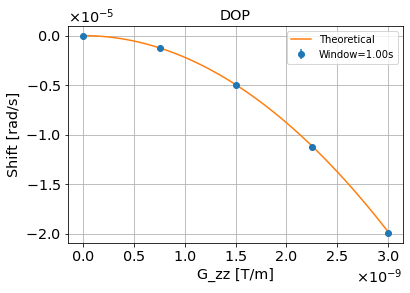

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


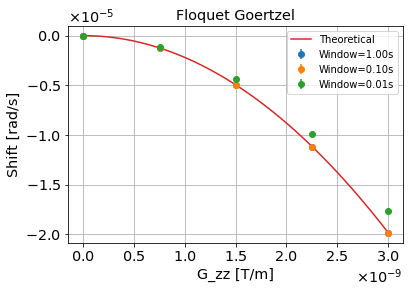

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


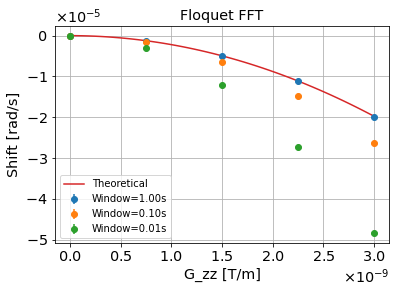

In [17]:
for it in iTypes:
    fig, ax = plt.subplots()
    for wlen in sorted(windowLengths)[::-1]:
        mask = (compiled_data['iType'] == it) & (compiled_data['ioutInt'] == wlen)
        if not np.any(mask) or wlen > 1:
            continue
        plt.errorbar(compiled_data[mask]['Gzz'], compiled_data[mask]['shift'], yerr=compiled_data[mask]['phase_error']/tf, fmt='o',
                    label='Window={:.2f}s'.format(wlen))
    pred_x = compiled_data[compiled_data['iType'] == 0]['Gzz']
    pred_y = compiled_data[compiled_data['iType'] == 0]['expected_shift']
    tx, ty = smooth_theory(pred_x, pred_y)
    plt.plot(tx, ty,
            label='Theoretical')
    ax.xaxis.set_major_formatter(get_formatter())  # Apply formatter to the x-axis
    ax.yaxis.set_major_formatter(get_formatter())  # Apply formatter to the y-axis
    plt.title(benchmarks.integrator_to_string(it))
    plt.legend()
    plt.xlabel('G_zz [T/m]')
    plt.ylabel('Shift [rad/s]')
    plt.grid()
    plt.savefig('B2_window_{:s}.eps'.format(benchmarks.integrator_to_string(it).replace(' ', '_')), bbox_inches='tight')
    plt.show()

In [18]:
dressing_B2_folder = 'dressing_B2_folder'

In [11]:
Gzz_range = np.linspace(0, 3e-9, num=5)
E_range = np.linspace(0, 1e7, num=5)

T_range = [0.25]
a_range = [3e-5]
parameter_tuples = [('0', '1.0'), ('6', '1.0'), ('7', '1.0')]
for _ in range(16):
    for (iType, ioutInt) in parameter_tuples:
        integration['integratorType'] = iType
        integration['ioutInt'] = ioutInt
        pb = benchmarks.DressingBenchmark(physics=physics, integration=integration,
                                            Gzz_range = Gzz_range,
                                            T_range = T_range,
                                            a_range = a_range,
                                            executable='../build/cuda/main', scratch_dir=os.path.join(scratch_dir, dressing_B2_folder))
        pb.run()

Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 15
iter 1, duration 1, 6015
{0.140134, -0.221564, 0.965024}
6420
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 13
iter 1, duration 1, 5892
{0.140133, -0.221565, 0.965024}
6179
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 5937
{0.14013, -0.221569, 0.965024}
6189
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 5814
{0.140134, -0.221575, 0.965022}
6069
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 13
iter 1, duration 1, 5930
{0.140126, -0.221583, 0.965021}
6205
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
it

iter 0, duration 0, 13
iter 1, duration 1, 6035
{0.140134, -0.221564, 0.965024}
6303
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 13
iter 1, duration 1, 5922
{0.140135, -0.221565, 0.965024}
6190
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 13
iter 1, duration 1, 5926
{0.140134, -0.221569, 0.965023}
6192
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 12
iter 1, duration 1, 5894
{0.140136, -0.221575, 0.965021}
6150
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 11
iter 1, duration 1, 5872
{0.140137, -0.221583, 0.965019}
6208
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2411
{0.140134, -0.221564, 0.965024}
2710
 
Knudsen N

 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 13
iter 1, duration 1, 6004
{0.140134, -0.221565, 0.965024}
6294
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 14
iter 1, duration 1, 5958
{0.140134, -0.221569, 0.965023}
6230
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 13
iter 1, duration 1, 5898
{0.140134, -0.221575, 0.965022}
6165
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 13
iter 1, duration 1, 5869
{0.14013, -0.221583, 0.96502}
6123
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2389
{0.140134, -0.221564, 0.965024}
2649
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
it

iter 0, duration 0, 12
iter 1, duration 1, 5906
{0.140134, -0.221565, 0.965024}
6179
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 13
iter 1, duration 1, 5891
{0.140133, -0.221569, 0.965023}
6155
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 13
iter 1, duration 1, 5837
{0.140129, -0.221575, 0.965022}
6097
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 11
iter 1, duration 1, 5789
{0.140135, -0.221583, 0.96502}
6063
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 5
iter 1, duration 1, 2394
{0.140134, -0.221564, 0.965024}
2657
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2383
{0.140134, -0.221565, 0.965024}
2644
 
Knudsen Num

iter 0, duration 0, 12
iter 1, duration 1, 5849
{0.140131, -0.221569, 0.965024}
6101
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 13
iter 1, duration 1, 5884
{0.140133, -0.221575, 0.965022}
6141
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 13
iter 1, duration 1, 5960
{0.140137, -0.221583, 0.965019}
6208
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2394
{0.140134, -0.221564, 0.965024}
2668
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 5
iter 1, duration 1, 2389
{0.140134, -0.221565, 0.965024}
2657
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2436
{0.140134, -0.221569, 0.965023}
2712
 
Knudsen Num

 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 13
iter 1, duration 1, 6027
{0.140132, -0.221575, 0.965022}
6287
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 13
iter 1, duration 1, 5892
{0.140131, -0.221583, 0.96502}
6142
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2393
{0.140134, -0.221564, 0.965024}
2669
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2410
{0.140134, -0.221565, 0.965024}
2666
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 6
iter 1, duration 1, 2401
{0.140134, -0.221569, 0.965023}
2660
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
ite

In [19]:
pb = benchmarks.DressingBenchmark(physics=physics, integration=integration,
                                    executable='../build/cuda/main', scratch_dir=os.path.join(scratch_dir, dressing_B2_folder))
data = pb.analyze(files=glob.glob(os.path.join(scratch_dir, dressing_B2_folder, 'out_*.hdf5')))
Gvalues = set(data['Gzz'])
iTypes = set(data['iType'])
c = benchmarks.Collector()
for it, gzz in itertools.product(iTypes, Gvalues):
    mask = (data['Gzz'] == gzz) & (data['iType'] == it)
    true_phase_error = benchmarks.phase_std(np.array(data[mask]['phi']))/np.sqrt(len(data[mask]))
    c.new_record()
    c.add('tf', data[mask]['tf'].iloc[0])
    c.add('Gzz', gzz)
    c.add('phi', np.mean(data[mask]['phi']))
    c.add('phase_error', true_phase_error)
    c.add('iType', it)
    c.add('expected_shift', data[mask]['expected_shift'].iloc[0])
    c.add('shift', np.mean(data[mask]['shift']))
compiled_data = c.to_pandas().sort_values('Gzz')
tf = compiled_data['tf'].iloc[0]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


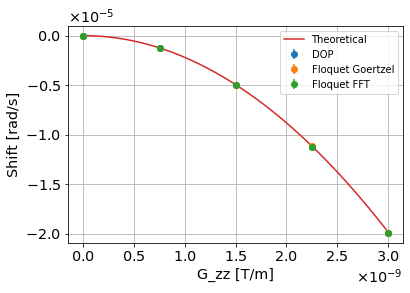

In [20]:
fig, ax = plt.subplots()
for it in iTypes:
    mask = compiled_data['iType'] == it
    plt.errorbar(compiled_data[mask]['Gzz'], compiled_data[mask]['shift'], yerr=compiled_data[mask]['phase_error']/tf, fmt='o',
                label='{:s}'.format(benchmarks.integrator_to_string(it)))

pred_x = compiled_data[compiled_data['iType'] == 0]['Gzz']
pred_y = compiled_data[compiled_data['iType'] == 0]['expected_shift']
tx, ty = smooth_theory(pred_x, pred_y)
plt.plot(tx, ty,
        label='Theoretical')
ax.xaxis.set_major_formatter(get_formatter())  # Apply formatter to the x-axis
ax.yaxis.set_major_formatter(get_formatter())  # Apply formatter to the y-axis
plt.legend()
plt.xlabel('G_zz [T/m]')
plt.ylabel('Shift [rad/s]')
plt.grid()
plt.savefig('B2_dress.eps', bbox_inches='tight')

In [7]:
dressing_E2_folder = 'dressing_E2'

In [8]:
E_range = np.linspace(0, 1e7, num=5)
T_range = [0.25]
a_range = [3e-5]
for _ in range(8):
    for (iType, ioutInt) in [('0', '1.0'), ('6', '1.0'), ('7', '1.0')]:
        integration['integratorType'] = iType
        integration['ioutInt'] = ioutInt
        pb = benchmarks.DressingBenchmark(physics=physics, integration=integration,
                                            E_range = E_range,
                                            T_range = T_range,
                                            a_range = a_range,
                                            executable='../build/cuda/main', scratch_dir=os.path.join(scratch_dir, dressing_E2_folder))
        pb.run()

Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 25


KeyboardInterrupt: 

In [95]:
importlib.reload(benchmarks)

<module 'benchmarks' from '/storage/home/hcodaman1/rtat3/Spin-tracking/benchmarks/benchmarks.py'>

In [96]:
###############
# E2 analysis #
###############

pb = benchmarks.DressingBenchmark(physics=physics, integration=integration,
                                    executable='../build/cuda/main', scratch_dir=os.path.join(scratch_dir, dressing_E2_folder))
filelist = glob.glob(os.path.join(scratch_dir, dressing_E2_folder, 'out_*.hdf5'))
data = pb.analyze(files=filelist)

In [97]:
Evalues = set(data['E'])
iTypes = set(data['iType'])
end_times = set(data['tf'])
c = benchmarks.Collector()
for it, E, t_end in itertools.product(iTypes, Evalues, end_times):
    mask = (data['E'] == E) & (data['iType'] == it) & (data['tf'] == t_end)
    true_phase_error = benchmarks.phase_std(np.array(data[mask]['phi']))/np.sqrt(len(data[mask]))
    c.new_record()
    c.add('tf', data[mask]['tf'].iloc[0])
    c.add('E', E)
    c.add('phi', np.mean(data[mask]['phi']))
    c.add('phase_error', true_phase_error)
    c.add('iType', it)
    c.add('expected_shift', data[mask]['expected_shift'].iloc[0])
    c.add('shift', np.mean(data[mask]['shift']))
    c.add('sx', np.mean(data[mask]['sx']))
    c.add('sy', np.mean(data[mask]['sy']))
    c.add('sz', np.mean(data[mask]['sz']))
    c.add('smag', np.sqrt(np.mean(data[mask]['sx'])**2 + np.mean(data[mask]['sy'])**2 + np.mean(data[mask]['sz'])**2))

compiled_data = c.to_pandas().sort_values('E')
tf = compiled_data['tf'].iloc[0]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


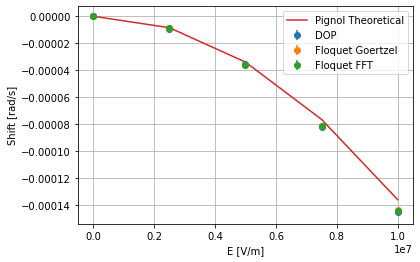

In [99]:
for it in iTypes:
    mask = compiled_data['iType'] == it
    plt.errorbar(compiled_data[mask]['E'], compiled_data[mask]['shift'], yerr=compiled_data[mask]['phase_error']/tf, fmt='o',
                label='{:s}'.format(benchmarks.integrator_to_string(it)))

plt.plot(compiled_data[compiled_data['iType'] == 0]['E'], compiled_data[compiled_data['iType'] == 0]['expected_shift'],
        label='Pignol Theoretical')
plt.legend()
plt.grid()
plt.xlabel('E [V/m]')
plt.ylabel('Shift [rad/s]')
plt.savefig('E2_dress.eps')

In [30]:
R.from_matrix(rotation_from_data(compiled_data, 0, E=-3e7)).as_rotvec()

array([-3.10207318e+00,  3.96257541e-05,  4.49103343e-01])

In [66]:
def slice_rot_vec(i0, E_obs):
    Evalues = set(data['E'])
    iTypes = set(data['iType'])
    end_times = set(data['tf'])
    c = benchmarks.Collector()
    for it, E, t_end in itertools.product(iTypes, Evalues, end_times):
        mask = (data['E'] == E) & (data['iType'] == it) & (data['tf'] == t_end)
        true_phase_error = benchmarks.phase_std(np.array(data[mask]['phi']))/np.sqrt(len(data[mask]))
        c.new_record()
        c.add('tf', data[mask]['tf'].iloc[0])
        c.add('E', E)
        c.add('phi', np.mean(data[mask]['phi']))
        c.add('phase_error', true_phase_error)
        c.add('iType', it)
        c.add('expected_shift', data[mask]['expected_shift'].iloc[0])
        c.add('shift', np.mean(data[mask]['shift']))
        c.add('sx', np.mean(data[mask].iloc[i0:i0+1]['sx']))
        c.add('sy', np.mean(data[mask].iloc[i0:i0+1]['sy']))
        c.add('sz', np.mean(data[mask].iloc[i0:i0+1]['sz']))
        c.add('smag', np.sqrt(np.mean(data[mask]['sx'])**2 + np.mean(data[mask]['sy'])**2 + np.mean(data[mask]['sz'])**2))

    compiled_data = c.to_pandas().sort_values('E')
    tf = compiled_data['tf'].iloc[0]
    return R.from_matrix(rotation_from_data(compiled_data, 0, E=E_obs)).as_rotvec()

(array([ 6.,  1., 11., 16., 39., 13., 22.,  8.,  6.,  6.]),
 array([-0.03890218,  1.11913553,  2.27717324,  3.43521095,  4.59324867,
         5.75128638,  6.90932409,  8.0673618 ,  9.22539951, 10.38343723,
        11.54147494]),
 <BarContainer object of 10 artists>)

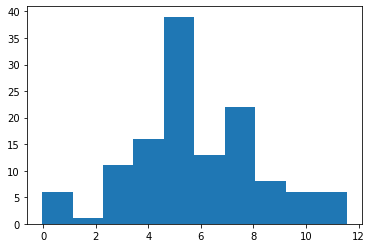

In [73]:
arr = [slice_rot_vec(i, -3e7)[1] for i in range(128)]
plt.hist(np.array(arr) * 1e5)

Text(0, 0.5, 'Shift [rad/s]')

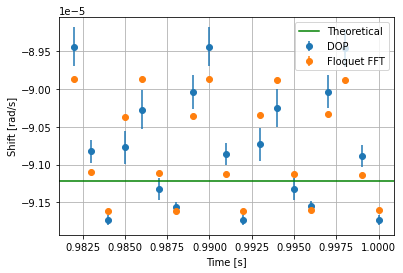

In [9]:
for it in iTypes:
    mask = (compiled_data['iType'] == it) & (compiled_data['E'] == 1e7)
    plt.errorbar(compiled_data[mask]['tf'], compiled_data[mask]['shift'], yerr=compiled_data[mask]['phase_error']/tf, fmt='o',
                label='{:s}'.format(benchmarks.integrator_to_string(it)))
plt.axhline(compiled_data[compiled_data['E'] == 1e7]['expected_shift'].iloc[0], label='Theoretical', color='green')
plt.legend()
plt.grid()
plt.xlabel('Time [s]')
plt.ylabel('Shift [rad/s]')

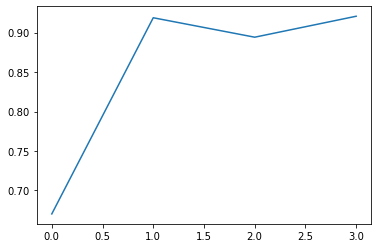

In [40]:
sfft = np.array(compiled_data[(compiled_data['iType'] == 7) & (compiled_data['E'] > 0)]['shift'])
sdop = np.array(compiled_data[(compiled_data['iType'] == 0) & (compiled_data['E'] > 0)]['shift'])
plt.plot(sfft/sdop)

In [7]:
EB_folder = 'dressing_EB_benchmark'

In [ ]:
integration['integratorType'] = '0'
integration['ioutInt'] = '1.0'
E_range = np.linspace(-1e6, 1e6, num=11)
#E_range = [1e6]
Gzz_range = [3e-10]
T_range = [0.25]
a_range = [3e-5]
parameter_tuples = [('0', '1.0'), ('6', '1.0'), ('7', '1.0')]

for _ in range(16):
    for (iType, ioutInt) in parameter_tuples:
        integration['integratorType'] = iType
        integration['ioutInt'] = ioutInt
        pb = benchmarks.DressingBenchmark(physics=physics, integration=integration,
                                            E_range = E_range,
                                            Gzz_range = Gzz_range,
                                            T_range=T_range,
                                            a_range=a_range,
                                            executable='../build/cuda/main', scratch_dir=os.path.join(scratch_dir, EB_folder))
        pb.run()

Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 22
iter 1, duration 1, 5875
{0.140128, -0.221566, 0.965025}
6278
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 19
iter 1, duration 1, 5908
{0.140133, -0.221564, 0.965024}
6185
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 19
iter 1, duration 1, 5923
{0.140132, -0.221565, 0.965024}
6229
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 19
iter 1, duration 1, 5776
{0.140132, -0.221565, 0.965024}
6086
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
iter 0, duration 0, 19
iter 1, duration 1, 5806
{0.140133, -0.221564, 0.965024}
6103
 
Knudsen Number: 1.55e-01
Adiabaticity: 3.89e+02
w0 * tc: 9.31e+00
Regime: diffusive adiabatic
i

In [6]:
pb = benchmarks.PignolBenchmark(physics=physics, integration=integration,
                                    executable='../build/cuda/main', scratch_dir=os.path.join(scratch_dir, EB_folder))
data = pb.analyze(files=glob.glob(os.path.join(scratch_dir, EB_folder, 'out_*.hdf5')))
Evalues = set(data['E'])
iTypes = set(data['iType'])
c = benchmarks.Collector()
for it, ev in itertools.product(iTypes, Evalues):
    mask = (data['E'] == ev) & (data['iType'] == it)
    true_phase_error = benchmarks.phase_std(np.array(data[mask]['phi']))/np.sqrt(len(data[mask]))
    c.new_record()
    c.add('tf', data[mask]['tf'].iloc[0])
    c.add('E', ev)
    c.add('phi', np.mean(data[mask]['phi']))
    c.add('phase_error', true_phase_error)
    c.add('iType', it)
    c.add('expected_shift', data[mask]['expected_shift'].iloc[0])
    c.add('shift', np.mean(data[mask]['shift']))
compiled_data = c.to_pandas().sort_values('E')
tf = compiled_data['tf'].iloc[0]

NameError: name 'EB_folder' is not defined

In [19]:
c = benchmarks.Collector()
Evalues = set(np.abs(compiled_data['E']))
iTypes = set(data['iType'])
c = benchmarks.Collector()
for it, ev in itertools.product(iTypes, Evalues):
    mask = ((data['E'] == ev) | (data['E'] == -ev)) & (data['iType'] == it)
    c.new_record()
    c.add('tf', data[mask]['tf'].iloc[0])
    c.add('E', ev)
    c.add('iType', it)
    c.add('expected_shift', np.mean(data[mask]['expected_shift'] * np.sign(data[mask]['E'])))
    c.add('shift', np.mean(data[mask]['shift'] * np.sign(data[mask]['E'])))
EB_data = c.to_pandas().sort_values('E')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


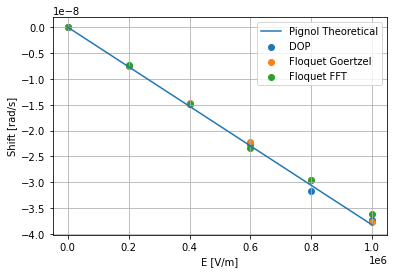

In [33]:
for it in iTypes:
    mask = EB_data['iType'] == it
    #print(compiled_data[mask].sort_values('E'))
    plt.scatter(EB_data[mask]['E'], EB_data[mask]['shift'],
                label='{:s}'.format(benchmarks.integrator_to_string(it)))

plt.plot(EB_data[EB_data['iType'] == 0]['E'], EB_data[EB_data['iType'] == 0]['expected_shift'],
        label='Pignol Theoretical')
plt.legend()
plt.grid()
plt.xlabel('E [V/m]')
plt.ylabel('Shift [rad/s]')
plt.savefig('EB_shift.eps')